<a href="https://colab.research.google.com/github/solomon7-data/Athlete/blob/main/Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [150]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# import

In [151]:
data = pd.read_csv('https://raw.githubusercontent.com/solomon7-data/HIV_DATA1/main/HIV.csv', encoding='latin1')


In [152]:

data = data.transpose().reset_index()
data.columns = data.iloc[1]
data = data.iloc[2:]
df = data
df[['Activity','Clients receiving HIV test results (at VCT)','Clients testing positive for HIV (at VCT)','Clients receiving HIV test results (at PITC)','Clients testing positive for HIV (at PITC)']]

1,Activity,Clients receiving HIV test results (at VCT),Clients testing positive for HIV (at VCT),Clients receiving HIV test results (at PITC),Clients testing positive for HIV (at PITC)
2,Meskerem 2018,134,1,716,4
3,Tikemet 2018,100,1,679,6
4,Hidar 2018,107,2,706,3
5,Tahesas 2018,144,5,741,6
6,Tir 2018,118,1,661,4
7,Yekatit 2018,119,4,806,12
8,Megabit 2018,105,1,675,NaN
9,Miazia 2018,119,NaN,675,3
10,Genbot 2018,128,2,781,3
11,Sene 2018,126,1,799,9


In [153]:
df = data.fillna(0)

/tmp/ipykernel_3036/3551743364.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = data.fillna(0)


In [154]:
rename_cols = {'Activity':'yr_mnth',
 'Clients receiving HIV test results (at VCT)':'VCT',
 'Clients testing positive for HIV (at VCT)':'VCT_Pos',
 'Clients receiving HIV test results (at PITC)':'PITC',
 'Clients testing positive for HIV (at PITC)':'PITC_Pos',
 'Number of index cases offered':'ICT_offered',
 'Number of contacts elicited':'Elicited',
 'Number of contacts tested':'ICT_Testd',
 'New positive':'ICT_Pos',
 'Known positive':'ICT_known',
 'HIV_Number of Individual HIV self test KIT distributed':'Self_Test',
 'HIV_Children currently on ART':'COA_Adult',
 'HIV_Adults currently on ART':'COA_Pedy',
 'HIV_Number of children (<19) who are currently on ART by regimen type':'COA_<19',
 'Number of adults and children with HIV infection newly started on ART':'TX_New',
 'Linkage outcome of newly identified Hiv positive individuals in the reporting period':'Linked',
 'Linked to Care and Treatment':'Initiated',
 'Known on ART':'known',
 'Lost to follow-up':'Lost',
 'Number of adult and pediatric ART patients for whom viral load test result received in the reporting period':'VL_Recieved',
 'Total number of adult and paediatric ART patients with an undetectable viral load(<50 copies/ml) in the reporting period':'supressed',
 'Total number of adult and paediatric ART patients with low level viremia (50 -1000 copies/ml) in the reporting period':'LVL',
 'Total number of clients on 3MMD':'3MMD',
 'Total number of clients on ASM(6MMD)':'ASM(6MMD)',
 'Total number of clients on FTAR':'FTAR',
 'Total number of clients on CAG':'CAG',
 'Total number of clients on PCAD':'PCAD',
 'Total number of clients on Adolescent DSD':'Adolescent DSD',
 'Total number of clients on KP DSD':'KP DSD',
 'Total number of clients on MCH DSD':'MCH DSD',
 'Total number of clients on other types of DSD':'Other_DSD',
 'Total number of clients on Advanced HIV Disease Care Model':'AHD',
 'Commercial sex workers':'CSW_1',
 'PrEP Curr (Number of individuals that received oral PrEP during the reporting period)':'PrEP',
 'By age and Sex':'Prep_Curr',
 'Number of STI cases tested for HIV':'STI_HIV',
 'Number of STI cases tested positive for HIV':'STI_HIV_Pos',
 'Proportion of patients enrolled in HIV care who were screened for TB (FD)':'TB_Screened',
 'Number of NEWLY Enrolled ART clients who were screened for TB during the reporting period':'TB_Screened_new',
 'Screened Positive for TB':'Presumptive_TB',
 'HIV_Number of ART patients who started on a standard course of TB Preventive Treatment (TPT) in the reporting period':'TB_RX',
 'Cervical Cancer screening by type of test':'Cervical_screening',
 'Screened by VIA':'VIA',
 'Screened by HPV DNA':'HPV',
 'HIV_VIA Screening Result':'VIA_Result',
 'Normal cervix':'Negative',
 'Precancerous Lesion:':'Positive',
 'Suspecious cancerous Lesion:':'Suspected',
 'HPV DNA test positive:':'HPV_Pos',
 'HIV_Treatment of precancerous cervical lesion':'Cervical_Treatment',
 'Treatment with Cryotherapy':'Cryotherapy',
 'Treatment with ':'LEEP',
 'Treatment with Thermal Ablation/Thermocoagulation':'Thermocoagulation'}

In [155]:
df = df.rename(columns=rename_cols)
df = df.loc[:, ~df.columns.str.contains("Male|Female|years", case = False, na = False)]


In [156]:
cols_to_keep = [
 'yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 'Cervical_Treatment',
 'Cryotherapy',
 'Treatment with LEEP',
 'Thermocoagulation']

In [157]:
df = df[cols_to_keep]

In [158]:
df.head(12)

1,yr_mnth,VCT,VCT_Pos,PITC,PITC_Pos,ICT_offered,Elicited,ICT_Testd,ICT_Pos,ICT_known,...,HPV,VIA_Result,Normal cervix:,Positive,Suspected,HPV_Pos,Cervical_Treatment,Cryotherapy,Treatment with LEEP,Thermocoagulation
2,Meskerem 2018,134,1,716,4,41,62,16,0,4,...,0,59,56,3,0,0,3,0,2,1
3,Tikemet 2018,100,1,679,6,24,43,20,2,13,...,0,74,68,5,1,0,2,0,0,2
4,Hidar 2018,107,2,706,3,29,41,15,0,0,...,1,49,48,1,0,1,1,0,1,0
5,Tahesas 2018,144,5,741,6,45,58,44,2,0,...,0,7,5,2,0,0,1,0,0,1
6,Tir 2018,118,1,661,4,35,55,33,1,4,...,0,42,41,1,0,0,0,0,0,0
7,Yekatit 2018,119,4,806,12,41,48,27,4,11,...,0,42,39,1,2,0,0,0,0,0
8,Megabit 2018,105,1,675,0,18,25,21,0,0,...,33,3,2,1,0,9,0,0,0,0
9,Miazia 2018,119,0,675,3,12,13,16,0,0,...,36,77,77,0,0,1,0,0,0,0
10,Genbot 2018,128,2,781,3,22,30,9,0,4,...,30,16,14,2,0,6,1,0,0,1
11,Sene 2018,126,1,799,9,39,54,17,4,20,...,39,15,14,1,0,16,0,0,0,0


In [159]:
df.columns.to_list()

['yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Died',
 'Others',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'Discordant Couple',
 'CSW_1',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VI

In [160]:
df = df.loc[:, ~df.columns.duplicated()]

In [161]:
df.columns.to_list()

['yr_mnth',
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 '

In [162]:
numeric = [
 'VCT',
 'VCT_Pos',
 'PITC',
 'PITC_Pos',
 'ICT_offered',
 'Elicited',
 'ICT_Testd',
 'ICT_Pos',
 'ICT_known',
 'Self_Test',
 'COA_Adult',
 'COA_Pedy',
 'COA_<19',
 'TX_New',
 'Linked',
 'Initiated',
 'known',
 'Lost',
 'Referred',
 'Died',
 'Others',
 'VL_Recieved',
 'supressed',
 'LVL',
 '3MMD',
 'ASM(6MMD)',
 'FTAR',
 'CAG',
 'PCAD',
 'Adolescent DSD',
 'KP DSD',
 'MCH DSD',
 'Other_DSD',
 'AHD',
 'Number of ART clients restarted ARV treatment in the reporting period',
 'Number of individuals receiving Pre-Exposure Prophylaxis',
 'PrEP (New individuals newly enrolled on PrEP) by age and Sex',
 'PrEP (New individuals newly enrolled on PrEP) by Client Category',
 'Discordant Couple',
 'CSW_1',
 'PrEP',
 'Prep_Curr',
 'By Client Category',
 'TB_Screened',
 'TB_Screened_new',
 'Presumptive_TB',
 'Number of PLHIVs PREVIOUSLY on ART and screened for TB',
 'TB_RX',
 'Cervical_screening',
 'VIA',
 'HPV',
 'VIA_Result',
 'Normal cervix:',
 'Positive',
 'Suspected',
 'HPV_Pos',
 'Cervical_Treatment',
 'Cryotherapy',
 'Treatment with LEEP',
 'Thermocoagulation']

In [163]:
df[numeric] = df[numeric].apply(pd.to_numeric,errors='coerce').round(0)
df[['month','year']] = df['yr_mnth'].str.split(' ',expand = True)


In [164]:
df['total_test'] = df['VCT'] + df['PITC']
df['total_pos'] = df['VCT_Pos'] + df['PITC_Pos']

In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 2 to 14
Data columns (total 65 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   yr_mnth                                                                13 non-null     object 
 1   VCT                                                                    12 non-null     float64
 2   VCT_Pos                                                                13 non-null     int64  
 3   PITC                                                                   12 non-null     float64
 4   PITC_Pos                                                               13 non-null     int64  
 5   ICT_offered                                                            13 non-null     int64  
 6   Elicited                                                               13 non-null     int64

In [166]:
df.head(10)

1,yr_mnth,VCT,VCT_Pos,PITC,PITC_Pos,ICT_offered,Elicited,ICT_Testd,ICT_Pos,ICT_known,...,Suspected,HPV_Pos,Cervical_Treatment,Cryotherapy,Treatment with LEEP,Thermocoagulation,month,year,total_test,total_pos
2,Meskerem 2018,134.0,1,716.0,4,41,62,16,0,4,...,0,0,3,0,2,1,Meskerem,2018,850.0,5
3,Tikemet 2018,100.0,1,679.0,6,24,43,20,2,13,...,1,0,2,0,0,2,Tikemet,2018,779.0,7
4,Hidar 2018,107.0,2,706.0,3,29,41,15,0,0,...,0,1,1,0,1,0,Hidar,2018,813.0,5
5,Tahesas 2018,144.0,5,741.0,6,45,58,44,2,0,...,0,0,1,0,0,1,Tahesas,2018,885.0,11
6,Tir 2018,118.0,1,661.0,4,35,55,33,1,4,...,0,0,0,0,0,0,Tir,2018,779.0,5
7,Yekatit 2018,119.0,4,806.0,12,41,48,27,4,11,...,2,0,0,0,0,0,Yekatit,2018,925.0,16
8,Megabit 2018,105.0,1,675.0,0,18,25,21,0,0,...,0,9,0,0,0,0,Megabit,2018,780.0,1
9,Miazia 2018,119.0,0,675.0,3,12,13,16,0,0,...,0,1,0,0,0,0,Miazia,2018,794.0,3
10,Genbot 2018,128.0,2,781.0,3,22,30,9,0,4,...,0,6,1,0,0,1,Genbot,2018,909.0,5
11,Sene 2018,126.0,1,799.0,9,39,54,17,4,20,...,0,16,0,0,0,0,Sene,2018,925.0,10


In [167]:
convert_month = {'Meskerem':'September',
 'Tikemet':'October',
 'Hidar':'November',
 'Tahesas': 'December',
 'Tir': 'January',
 'Yekatit':'February',
 'Megabit': 'March',
 'Miazia': 'April',
 'Genbot': 'May',
 'Sene': 'June',
 'Hamle': 'July',
 'Nehase': 'August'}

In [168]:
categories = df['month'].unique()
month_order = ['September', 'October', 'November', 'December','January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']

In [169]:
df['month_gc'] = df['month'].map(convert_month)

df['month_gc'] = pd.Categorical(df['month_gc'],categories=month_order,ordered=True)



# Dashboard

/tmp/ipykernel_3036/603475697.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_test = df.groupby('month_gc')['total_test'].sum()
/tmp/ipykernel_3036/603475697.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_pos = df.groupby('month_gc')['total_pos'].sum()
/tmp/ipykernel_3036/603475697.py:60: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vct_test = df.groupby('month_gc')['VCT'].sum()
/tmp/ipykernel_303

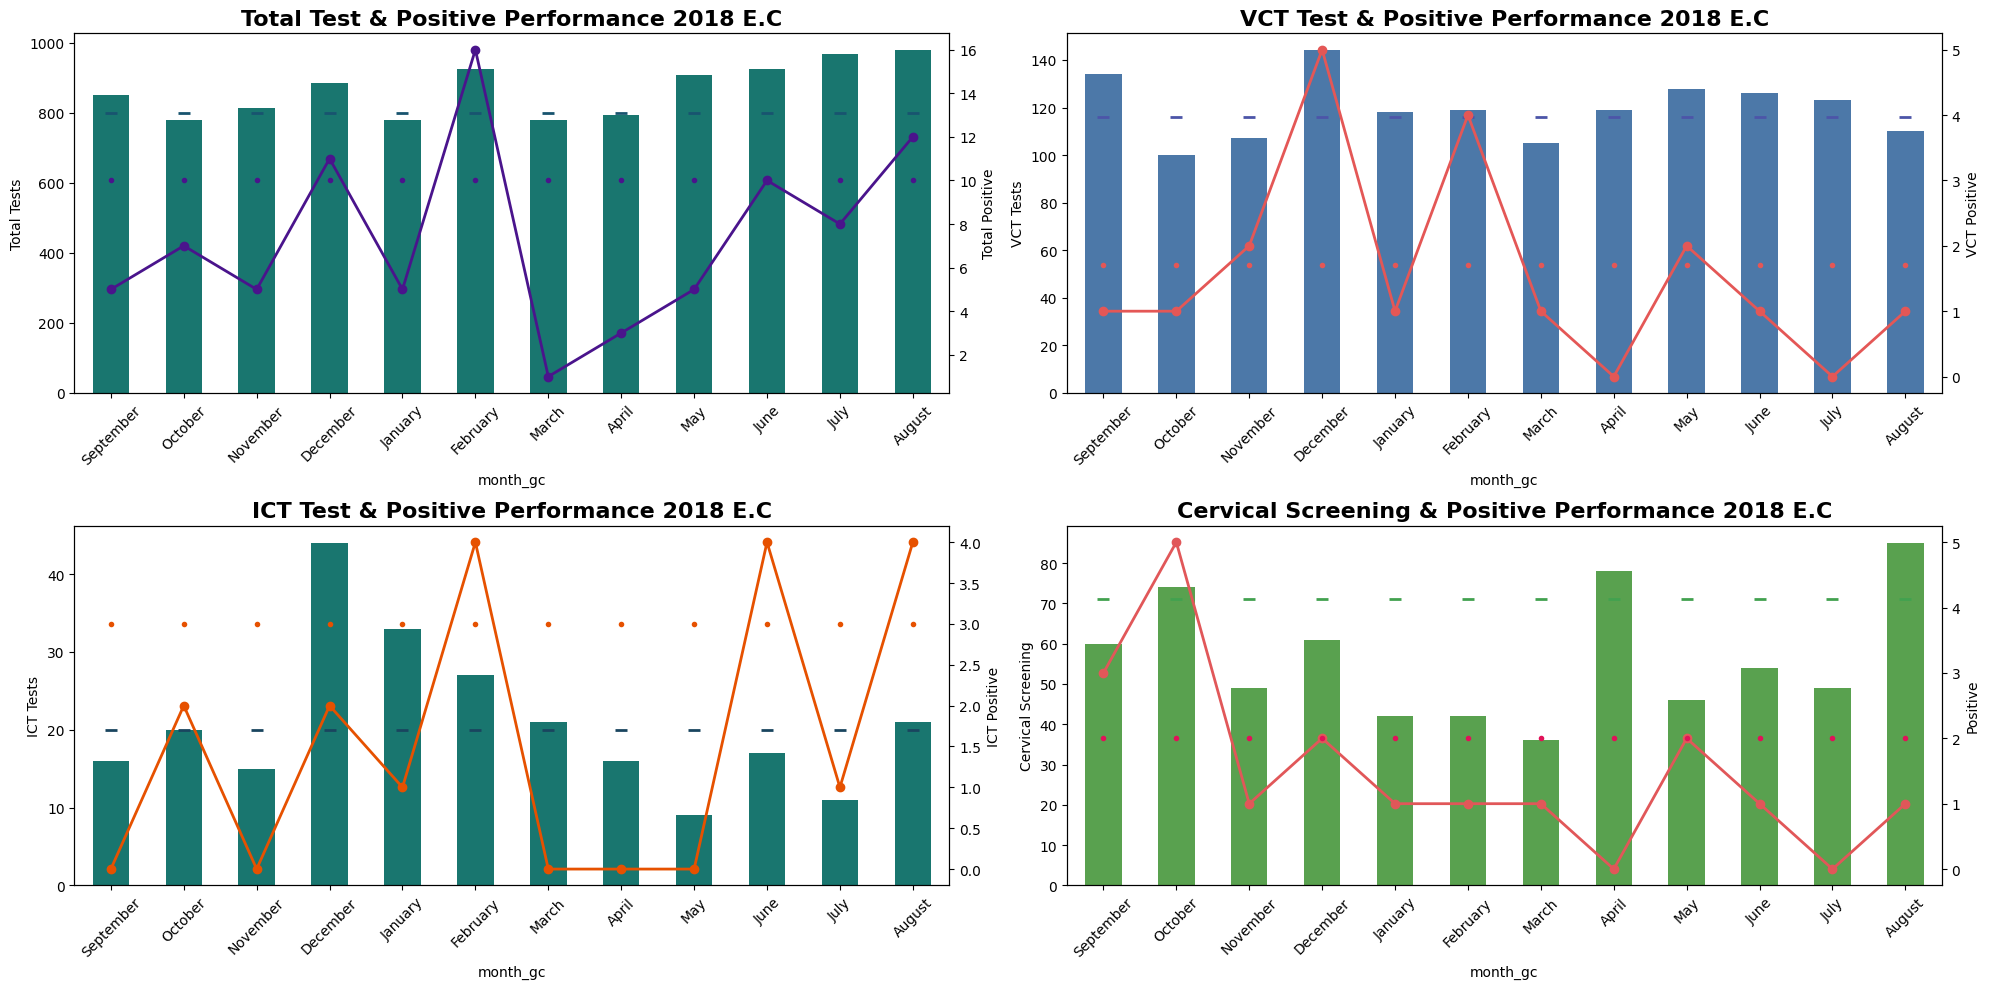

In [170]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 2, figsize=(20, 10))


# =========================================================
# 1. TOTAL TEST & POSITIVE
# =========================================================

total_test = df.groupby('month_gc')['total_test'].sum()
total_pos = df.groupby('month_gc')['total_pos'].sum()

test_target = 800
pos_target = 10

bars = total_test.plot(kind='bar',ax=axes[0, 0],color='#19766F')

ax2 = axes[0, 0].twinx()

total_pos.plot(kind='line',marker='o',color='#4A148C',ax=ax2,linewidth=2)

# ---- Test target dots/dashes on bars ----
for bar in bars.patches:
    x = bar.get_x()
    width = bar.get_width()

    axes[0, 0].plot(
        x + width / 2,
        test_target,
        marker='_',
        markersize=8,
        markeredgewidth=2,
        color='#18546F'
    )

# ---- Positive target dots on secondary axis ----
for x in range(len(total_pos)):
    ax2.plot(
        x,
        pos_target,
        marker='o',
        markersize=2,
        markeredgewidth=2,
        color='#4A148C'
    )

axes[0, 0].set_ylabel('Total Tests')
ax2.set_ylabel('Total Positive')

axes[0, 0].set_title('Total Test & Positive Performance 2018 E.C',fontsize=16,fontweight='bold',fontname='Times New Roman')

axes[0, 0].tick_params(axis='x', rotation=45)


# =========================================================
# 2. VCT
# =========================================================

vct_test = df.groupby('month_gc')['VCT'].sum()
vct_pos = df.groupby('month_gc')['VCT_Pos'].sum()

vct_test_target = 116
vct_pos_target = 1.7

bars = vct_test.plot(kind='bar',ax=axes[0, 1],color='#4C78A8')

ax2 = axes[0, 1].twinx()

vct_pos.plot(kind='line',marker='o',color='#E45756',ax=ax2,linewidth=2)

# ---- VCT Test target ----
for bar in bars.patches:
    x = bar.get_x()
    width = bar.get_width()

    axes[0, 1].plot(x + width / 2,vct_test_target,marker='_',markersize=8,markeredgewidth=2,color='#4C55A8')

# ---- VCT Positive target ----
for x in range(len(vct_pos)):
    ax2.plot(
        x,
        vct_pos_target,
        marker='o',
        markersize=2,
        markeredgewidth=2,
        color='#E45756'
    )

axes[0, 1].set_ylabel('VCT Tests')
ax2.set_ylabel('VCT Positive')

axes[0, 1].set_title('VCT Test & Positive Performance 2018 E.C',fontsize=16,fontweight='bold',fontname='Times New Roman')

axes[0, 1].tick_params(axis='x', rotation=45)

# =========================================================
# 3. ICT
# =========================================================

ict_test = df.groupby('month_gc')['ICT_Testd'].sum()
ict_pos = df.groupby('month_gc')['ICT_Pos'].sum()

ict_test_target = 20
ict_pos_target = 3

bars = ict_test.plot(
    kind='bar',
    ax=axes[1, 0],
    color='#19766F'
)

ax2 = axes[1, 0].twinx()

ict_pos.plot(kind='line', marker='o',color='#E65100',ax=ax2,linewidth=2)

# ---- ICT Test target ----
for bar in bars.patches:
    x = bar.get_x()
    width = bar.get_width()

    axes[1, 0].plot(x + width / 2,ict_test_target,marker='_',markersize=8,markeredgewidth=2,color='#19455F')

# ---- ICT Positive target ----
for x in range(len(ict_pos)):
    ax2.plot(
        x,
        ict_pos_target,
        marker='o',
        markersize=2,
        markeredgewidth=2,
        color='#E65100'
    )

axes[1, 0].set_ylabel('ICT Tests')
ax2.set_ylabel('ICT Positive')

axes[1, 0].set_title('ICT Test & Positive Performance 2018 E.C',fontsize=16,fontweight='bold',fontname='Times New Roman')

axes[1, 0].tick_params(axis='x', rotation=45)


# =========================================================
# 4. CERVICAL SCREENING
# =========================================================

cervical = df.groupby('month_gc')['Cervical_screening'].sum()
cervical_pos = df.groupby('month_gc')['Positive'].sum()

cervical_target = 71
cervical_pos_target = 2

bars = cervical.plot(kind='bar',ax=axes[1, 1],color='#59A14F')

ax2 = axes[1, 1].twinx()

cervical_pos.plot(kind='line', marker='o', color='#E15759',ax=ax2,linewidth=2)

# ---- Cervical screening target ----
for bar in bars.patches:
    x = bar.get_x()
    width = bar.get_width()

    axes[1, 1].plot(x + width / 2,cervical_target,marker='_',markersize=8,markeredgewidth=2,color='#42A14F')

# ---- Cervical positive target ----
for x in range(len(cervical_pos)):
    ax2.plot(
        x,
        cervical_pos_target,
        marker='o',
        markersize=2,
        markeredgewidth=2,
        color='#E11259')

axes[1, 1].set_ylabel('Cervical Screening')
ax2.set_ylabel('Positive')

axes[1, 1].set_title('Cervical Screening & Positive Performance 2018 E.C',fontsize=16,fontweight='bold',fontname='Times New Roman')

axes[1, 1].tick_params(axis='x', rotation=45)


# =========================================================
# COMMON LEGEND
# =========================================================



# Put target legend on the figure

plt.tight_layout()
plt.show()